<a href="https://colab.research.google.com/github/carolsworld/NX_TSC/blob/main/OPCUANetwork_20250502_IsolationForest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Demonstration of using network packet files generated during the NX MCD simulation for developing Unsupervised Learning Model for Threat Detection using IsolationForest in sklearn library. The goal of this task is to identify behaviours related to writing commands to PLC for anomaly scoring.

#Background

We carried out a multi-stage attack simulation on the Digital Twin-based testbed on 2 May 2025 from around 11:41 to 14:39 (local time, London/UK). During Step 3 and Step 5 of the attack simulation, we have issued write requests from OPC UA Client via HMI or UA Expert. For Step 1, Step 2 and Step 4, there are no manual intervention on the physical process. Therefore, we only expect to see anomalies occurred during Step 3 and Step 5 of the attack simulation.

During the simulation run, we used Wireshark to collect network packet data between the OPC UA Server and OPC UA Client. The entire packet capture file (.pcapng with 981,717 packets) contains OPC UA traffic on 2 May 2025 from 09:33 to 14:33 (local time, London/UK). The packet capture is analysed using Zeek with OPC UA Plug-in. The output file named 'opcua_binary.log' generated by Zeek is used for predictive analytics. We have used several python scripts to preprocess the .log file into .csv file, prepared to right format and extracted the features. The data preprocessing stage (Step 2) in this noebook focuses on aggregate features for each 1-minute network traffic.

We use unsupervised learning (IsolationForest) to identify write behaviours for anomaly scoring on the attack simulation conducted on 2 May 2025. Based on the empirical study in separate notebook, based on F1-score on the evaluation set, we identified containmination parameter of 0.25 is an optimal value for model training and testing.

The goal of this notebook is to obtain the 1-minute anomaly score for the OPC UA traffic on 2 May 2025 from 09:33 to 14:33 (local time, London/UK). The resulting .csv file will be used for decision fusion with process data generated from Siemens NX MCD.

#Step 0 - Check GPU

In [1]:
# Turn on GPU T4

# Runtime > Change runtime type

gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)


Thu May  8 12:19:09 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   33C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

#Step 1 - File upload

In [2]:
# Upload csv file and check the number of rows and columns in the pandas dataframe
from google.colab import files
import io
import pandas as pd

uploaded = files.upload()

filename = next(iter(uploaded))

df = pd.read_csv(io.BytesIO(uploaded['20250502_opcua_binary_features.csv']))

print("The number of rows and columns in the csv file: ", df.shape)

Saving 20250502_opcua_binary_features.csv to 20250502_opcua_binary_features.csv
The number of rows and columns in the csv file:  (694330, 13)


Expected number of row is 694330 with 13 columns.

In [3]:
# Display the first few rows of the dataframe to check file format
df.head()

,ts,uid,id.orig_h,id.orig_p,id.resp_h,id.resp_p,is_orig,opcua_link_id,is_final,msg_size,identifier,is_WriteOps,write_msg_anomaly
0,2025-05-02 09:33:33.570758104+01:00,C8aaQt3adljDnFcXI5,10.12.25.3,57962,10.12.25.30,4840,1,bff7cdb35a0b8b6171,0,253,673.0,1,0
1,2025-05-02 09:33:33.571787119+01:00,C8aaQt3adljDnFcXI5,10.12.25.3,57962,10.12.25.30,4840,0,193f21cfe00f17a192,0,100,676.0,0,0
2,2025-05-02 09:33:33.575303078+01:00,C8aaQt3adljDnFcXI5,10.12.25.3,57962,10.12.25.30,4840,1,01af5b289f39b56c70,0,204,631.0,0,0
3,2025-05-02 09:33:33.576936007+01:00,C8aaQt3adljDnFcXI5,10.12.25.3,57962,10.12.25.30,4840,0,2f366368c3f9060b13,0,189,634.0,0,0
4,2025-05-02 09:33:33.671008110+01:00,C8aaQt3adljDnFcXI5,10.12.25.3,57962,10.12.25.30,4840,1,aae051d0b02b65349a,0,253,673.0,1,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 694330 entries, 0 to 694329
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   ts                 694330 non-null  object 
 1   uid                694330 non-null  object 
 2   id.orig_h          694330 non-null  object 
 3   id.orig_p          694330 non-null  int64  
 4   id.resp_h          694330 non-null  object 
 5   id.resp_p          694330 non-null  int64  
 6   is_orig            694330 non-null  int64  
 7   opcua_link_id      694330 non-null  object 
 8   is_final           694330 non-null  int64  
 9   msg_size           694330 non-null  int64  
 10  identifier         694330 non-null  float64
 11  is_WriteOps        694330 non-null  int64  
 12  write_msg_anomaly  694330 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 68.9+ MB


#Step 2 - Dataset preprocessing and feature extraction for instance-level anomaly detection (1 minute per instance)

In [5]:
# Convert identifier to numeric, drop invalid rows
df = df[df['identifier'] != '-'].copy()
df['identifier'] = pd.to_numeric(df['identifier'], errors='coerce')
df.dropna(subset=['identifier'], inplace=True)
df['identifier'] = df['identifier'].astype('Int64')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 694330 entries, 0 to 694329
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   ts                 694330 non-null  object
 1   uid                694330 non-null  object
 2   id.orig_h          694330 non-null  object
 3   id.orig_p          694330 non-null  int64 
 4   id.resp_h          694330 non-null  object
 5   id.resp_p          694330 non-null  int64 
 6   is_orig            694330 non-null  int64 
 7   opcua_link_id      694330 non-null  object
 8   is_final           694330 non-null  int64 
 9   msg_size           694330 non-null  int64 
 10  identifier         694330 non-null  Int64 
 11  is_WriteOps        694330 non-null  int64 
 12  write_msg_anomaly  694330 non-null  int64 
dtypes: Int64(1), int64(7), object(5)
memory usage: 69.5+ MB


In [7]:
# Set timestamp as index
df['ts'] = pd.to_datetime(df['ts'], errors='coerce')
df = df.set_index('ts').sort_index()

# Group by 1-minute window
minute_groups = df.groupby(pd.Grouper(freq='1min'))

# Aggregate features per minute
minute_summary = minute_groups.agg({
    'write_msg_anomaly': ['sum', 'mean'],
    'is_WriteOps': ['sum', 'mean'],
    'msg_size': 'count'
})

# Flatten column names
minute_summary.columns = ['_'.join(col).strip() for col in minute_summary.columns]
minute_summary = minute_summary.rename(columns={
    'write_msg_anomaly_sum': 'write_anomaly_count',
    'write_msg_anomaly_mean': 'write_anomaly_ratio',
    'is_WriteOps_sum': 'write_ops_count',
    'is_WriteOps_mean': 'write_ops_ratio',
    'msg_size_count': 'total_packets'
}).reset_index()

# Display the first few rows of the dataframe to check file format
minute_summary.head()

,ts,write_anomaly_count,write_anomaly_ratio,write_ops_count,write_ops_ratio,total_packets
0,2025-05-02 09:33:00+01:00,0,0.0,257,0.235348,1092
1,2025-05-02 09:34:00+01:00,0,0.0,570,0.234375,2432
2,2025-05-02 09:35:00+01:00,0,0.0,55,0.121681,452
3,2025-05-02 09:36:00+01:00,0,0.0,491,0.222373,2208
4,2025-05-02 09:37:00+01:00,0,0.0,557,0.234230,2378


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 694330 entries, 2025-05-02 09:33:33.570758104+01:00 to 2025-05-02 14:33:43.671427965+01:00
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   uid                694330 non-null  object
 1   id.orig_h          694330 non-null  object
 2   id.orig_p          694330 non-null  int64 
 3   id.resp_h          694330 non-null  object
 4   id.resp_p          694330 non-null  int64 
 5   is_orig            694330 non-null  int64 
 6   opcua_link_id      694330 non-null  object
 7   is_final           694330 non-null  int64 
 8   msg_size           694330 non-null  int64 
 9   identifier         694330 non-null  Int64 
 10  is_WriteOps        694330 non-null  int64 
 11  write_msg_anomaly  694330 non-null  int64 
dtypes: Int64(1), int64(7), object(4)
memory usage: 69.5+ MB


#Step 3 - Predictive Analytics with Unsupervised Machine Learning

IsolationForest, 0.25 containmination parameter

In [11]:
# Import library
from google.colab import files
import pickle
from sklearn.ensemble import IsolationForest

In [12]:
# Upload the trained Isolation Forest model
uploaded = files.upload()

with open('iso_forest_025.pkl', 'rb') as f:
    iso_025 = pickle.load(f)

Saving iso_forest_025.pkl to iso_forest_025.pkl


In [13]:
# Prepare the feature set (same as used in training)
features_for_iforest = ['write_anomaly_count', 'write_anomaly_ratio', 'write_ops_ratio']
X_all = minute_summary[features_for_iforest]

In [14]:
# Predict anoamly scores
minute_summary['anomaly_score_0.25'] = iso_025.decision_function(X_all)  # higher = more normal
minute_summary['anomaly_0.25'] = iso_025.predict(X_all)                  # -1 = anomaly, 1 = normal

In [15]:
#Display results
display(minute_summary.head())

,ts,write_anomaly_count,write_anomaly_ratio,write_ops_count,write_ops_ratio,total_packets,anomaly_score_0.25,anomaly_0.25
0,2025-05-02 09:33:00+01:00,0,0.0,257,0.235348,1092,-0.007075,-1
1,2025-05-02 09:34:00+01:00,0,0.0,570,0.234375,2432,0.015944,1
2,2025-05-02 09:35:00+01:00,0,0.0,55,0.121681,452,-0.282645,-1
3,2025-05-02 09:36:00+01:00,0,0.0,491,0.222373,2208,-0.282645,-1
4,2025-05-02 09:37:00+01:00,0,0.0,557,0.234230,2378,0.146823,1


In [16]:
minute_summary.to_csv("minute_OPCUA_anomaly_summary.csv", index=False)

In [27]:
# Define interpretation function
def interpret_anomaly(score):
    if score < -0.05:
        return 'Network - Anomaly'
    elif score > 0.05:
        return 'Network - Normal'
    else:
        return 'Network - Marginal'

# Apply classification
minute_summary['Network_Label_3Class'] = minute_summary['anomaly_score_0.25'].apply(interpret_anomaly)

# Display some results
minute_summary[['ts', 'anomaly_score_0.25', 'Network_Label_3Class']].head()

,ts,anomaly_score_0.25,Network_Label_3Class
0,2025-05-02 09:33:00+01:00,-0.007075,Network - Marginal
1,2025-05-02 09:34:00+01:00,0.015944,Network - Marginal
2,2025-05-02 09:35:00+01:00,-0.282645,Network - Anomaly
3,2025-05-02 09:36:00+01:00,-0.282645,Network - Anomaly
4,2025-05-02 09:37:00+01:00,0.146823,Network - Normal


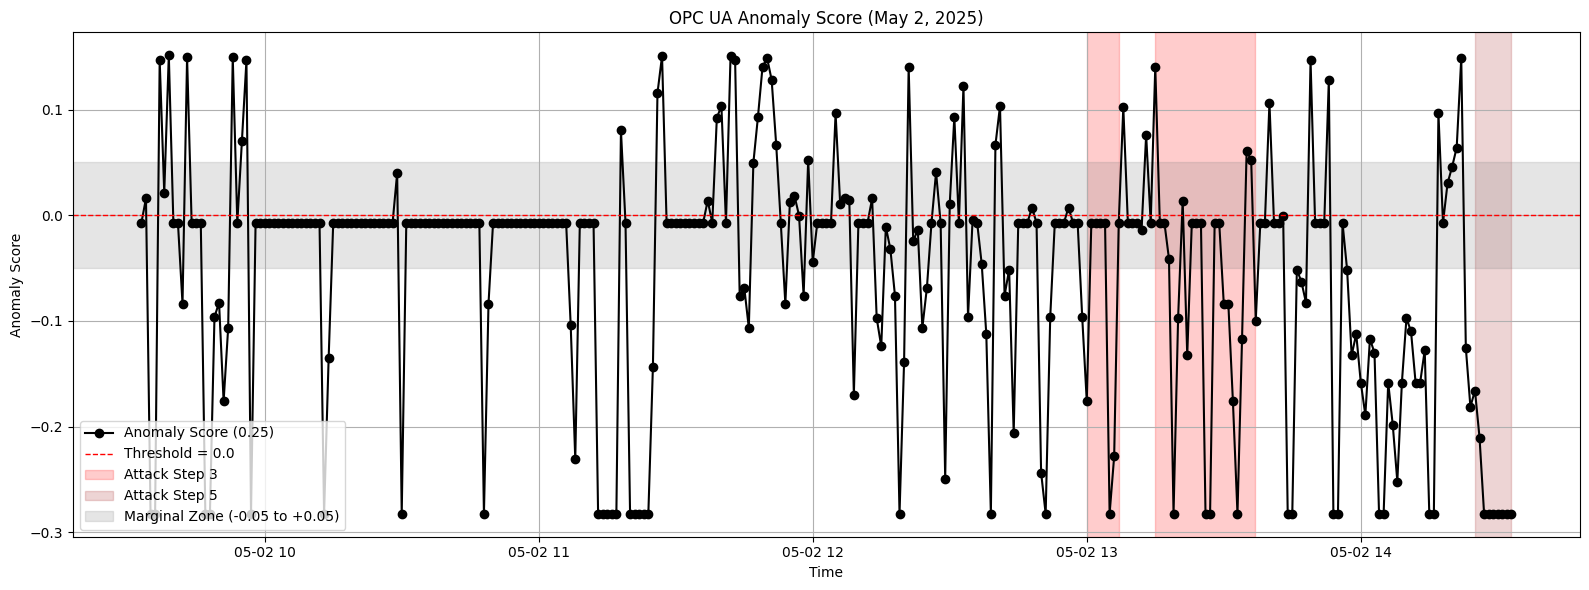

In [43]:
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(16, 6))
plt.plot(minute_summary['ts'], minute_summary['anomaly_score_0.25'], marker='o', linestyle='-', color='black', label='Anomaly Score (0.25)')

# Add horizontal threshold line
plt.axhline(y=0, color='red', linestyle='--', linewidth=1, label='Threshold = 0.0')

# Highlight attack step 3 - two separate spans
plt.axvspan(pd.to_datetime('2025-05-02 13:00:00+01:00'), pd.to_datetime('2025-05-02 13:07:00+01:00'),
            color='red', alpha=0.2, label='Attack Step 3')
plt.axvspan(pd.to_datetime('2025-05-02 13:15:00+01:00'), pd.to_datetime('2025-05-02 13:36:53+01:00'),
            color='red', alpha=0.2)

# Hightlight attack step 5
plt.axvspan(pd.to_datetime('2025-05-02 14:25:00+01:00'), minute_summary['ts'].max(),
            color='brown', alpha=0.2, label='Attack Step 5')

# Add marginal zone (horizontal band)
plt.axhspan(-0.05, 0.05, color='gray', alpha=0.2, label='Marginal Zone (-0.05 to +0.05)')

# Plot labels and legend
plt.title("OPC UA Anomaly Score (May 2, 2025)")
plt.xlabel("Time")
plt.ylabel("Anomaly Score")
plt.grid(True)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

In [30]:
minute_summary['Network_Label_3Class'].value_counts()

,count
Network_Label_3Class,
Network - Marginal,161
Network - Anomaly,104
Network - Normal,36


In [31]:
minute_summary['Network_Label_3Class'].value_counts(normalize=True) * 100

,proportion
Network_Label_3Class,
Network - Marginal,53.488372
Network - Anomaly,34.551495
Network - Normal,11.960133


In [33]:
anomaly_times = minute_summary[minute_summary['Network_Label_3Class'] == 'Network - Anomaly']['ts'].tolist()
anomaly_times

[Timestamp('2025-05-02 09:35:00+0100', tz='UTC+01:00'),
 Timestamp('2025-05-02 09:36:00+0100', tz='UTC+01:00'),
 Timestamp('2025-05-02 09:42:00+0100', tz='UTC+01:00'),
 Timestamp('2025-05-02 09:47:00+0100', tz='UTC+01:00'),
 Timestamp('2025-05-02 09:48:00+0100', tz='UTC+01:00'),
 Timestamp('2025-05-02 09:49:00+0100', tz='UTC+01:00'),
 Timestamp('2025-05-02 09:50:00+0100', tz='UTC+01:00'),
 Timestamp('2025-05-02 09:51:00+0100', tz='UTC+01:00'),
 Timestamp('2025-05-02 09:52:00+0100', tz='UTC+01:00'),
 Timestamp('2025-05-02 09:57:00+0100', tz='UTC+01:00'),
 Timestamp('2025-05-02 10:13:00+0100', tz='UTC+01:00'),
 Timestamp('2025-05-02 10:14:00+0100', tz='UTC+01:00'),
 Timestamp('2025-05-02 10:30:00+0100', tz='UTC+01:00'),
 Timestamp('2025-05-02 10:48:00+0100', tz='UTC+01:00'),
 Timestamp('2025-05-02 10:49:00+0100', tz='UTC+01:00'),
 Timestamp('2025-05-02 11:07:00+0100', tz='UTC+01:00'),
 Timestamp('2025-05-02 11:08:00+0100', tz='UTC+01:00'),
 Timestamp('2025-05-02 11:13:00+0100', tz='UTC+0

In [34]:
normal_times = minute_summary[minute_summary['Network_Label_3Class'] == 'Network - Normal']['ts'].tolist()
normal_times

[Timestamp('2025-05-02 09:37:00+0100', tz='UTC+01:00'),
 Timestamp('2025-05-02 09:39:00+0100', tz='UTC+01:00'),
 Timestamp('2025-05-02 09:43:00+0100', tz='UTC+01:00'),
 Timestamp('2025-05-02 09:53:00+0100', tz='UTC+01:00'),
 Timestamp('2025-05-02 09:55:00+0100', tz='UTC+01:00'),
 Timestamp('2025-05-02 09:56:00+0100', tz='UTC+01:00'),
 Timestamp('2025-05-02 11:18:00+0100', tz='UTC+01:00'),
 Timestamp('2025-05-02 11:26:00+0100', tz='UTC+01:00'),
 Timestamp('2025-05-02 11:27:00+0100', tz='UTC+01:00'),
 Timestamp('2025-05-02 11:39:00+0100', tz='UTC+01:00'),
 Timestamp('2025-05-02 11:40:00+0100', tz='UTC+01:00'),
 Timestamp('2025-05-02 11:42:00+0100', tz='UTC+01:00'),
 Timestamp('2025-05-02 11:43:00+0100', tz='UTC+01:00'),
 Timestamp('2025-05-02 11:48:00+0100', tz='UTC+01:00'),
 Timestamp('2025-05-02 11:49:00+0100', tz='UTC+01:00'),
 Timestamp('2025-05-02 11:50:00+0100', tz='UTC+01:00'),
 Timestamp('2025-05-02 11:51:00+0100', tz='UTC+01:00'),
 Timestamp('2025-05-02 11:52:00+0100', tz='UTC+0

In [36]:
marginal_times = minute_summary[minute_summary['Network_Label_3Class'] == 'Network - Marginal']['ts'].tolist()
marginal_times

[Timestamp('2025-05-02 09:33:00+0100', tz='UTC+01:00'),
 Timestamp('2025-05-02 09:34:00+0100', tz='UTC+01:00'),
 Timestamp('2025-05-02 09:38:00+0100', tz='UTC+01:00'),
 Timestamp('2025-05-02 09:40:00+0100', tz='UTC+01:00'),
 Timestamp('2025-05-02 09:41:00+0100', tz='UTC+01:00'),
 Timestamp('2025-05-02 09:44:00+0100', tz='UTC+01:00'),
 Timestamp('2025-05-02 09:45:00+0100', tz='UTC+01:00'),
 Timestamp('2025-05-02 09:46:00+0100', tz='UTC+01:00'),
 Timestamp('2025-05-02 09:54:00+0100', tz='UTC+01:00'),
 Timestamp('2025-05-02 09:58:00+0100', tz='UTC+01:00'),
 Timestamp('2025-05-02 09:59:00+0100', tz='UTC+01:00'),
 Timestamp('2025-05-02 10:00:00+0100', tz='UTC+01:00'),
 Timestamp('2025-05-02 10:01:00+0100', tz='UTC+01:00'),
 Timestamp('2025-05-02 10:02:00+0100', tz='UTC+01:00'),
 Timestamp('2025-05-02 10:03:00+0100', tz='UTC+01:00'),
 Timestamp('2025-05-02 10:04:00+0100', tz='UTC+01:00'),
 Timestamp('2025-05-02 10:05:00+0100', tz='UTC+01:00'),
 Timestamp('2025-05-02 10:06:00+0100', tz='UTC+0

The end